In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.transform import radon, iradon
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [2]:
image_path = 'C:/Users/Kirill/YandexDisk/Учёба/8 семестр/Обратные задачи/test1.jpg'
img = Image.open(image_path)
img_gray = rgb2gray(img)
image = np.array(img_gray) / 255.0


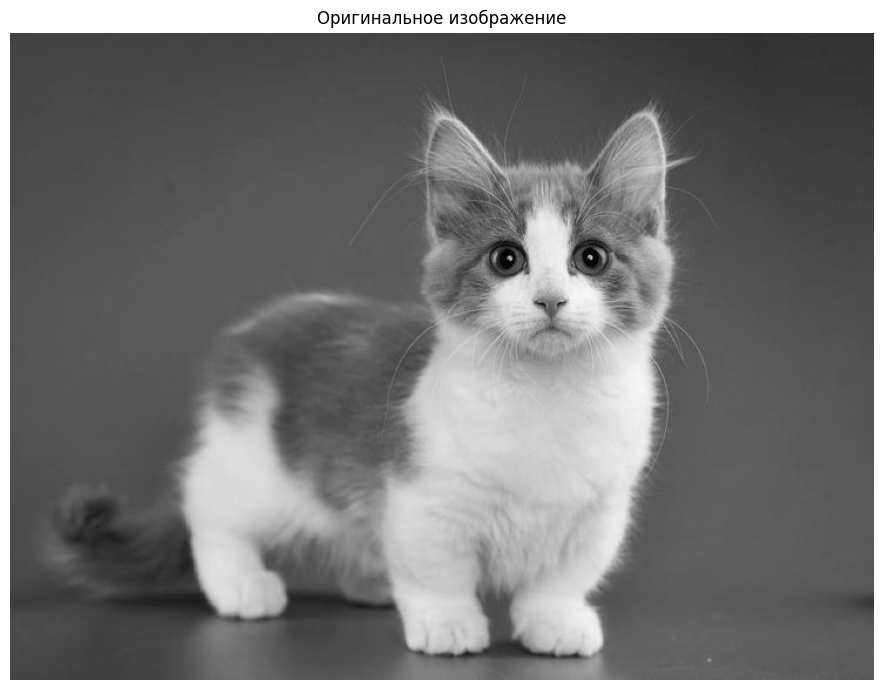

In [92]:
plt.figure(figsize=(15, 7))
plt.imshow(image, cmap='gray')
plt.title('Оригинальное изображение')
plt.axis('off')
plt.tight_layout()
plt.show()

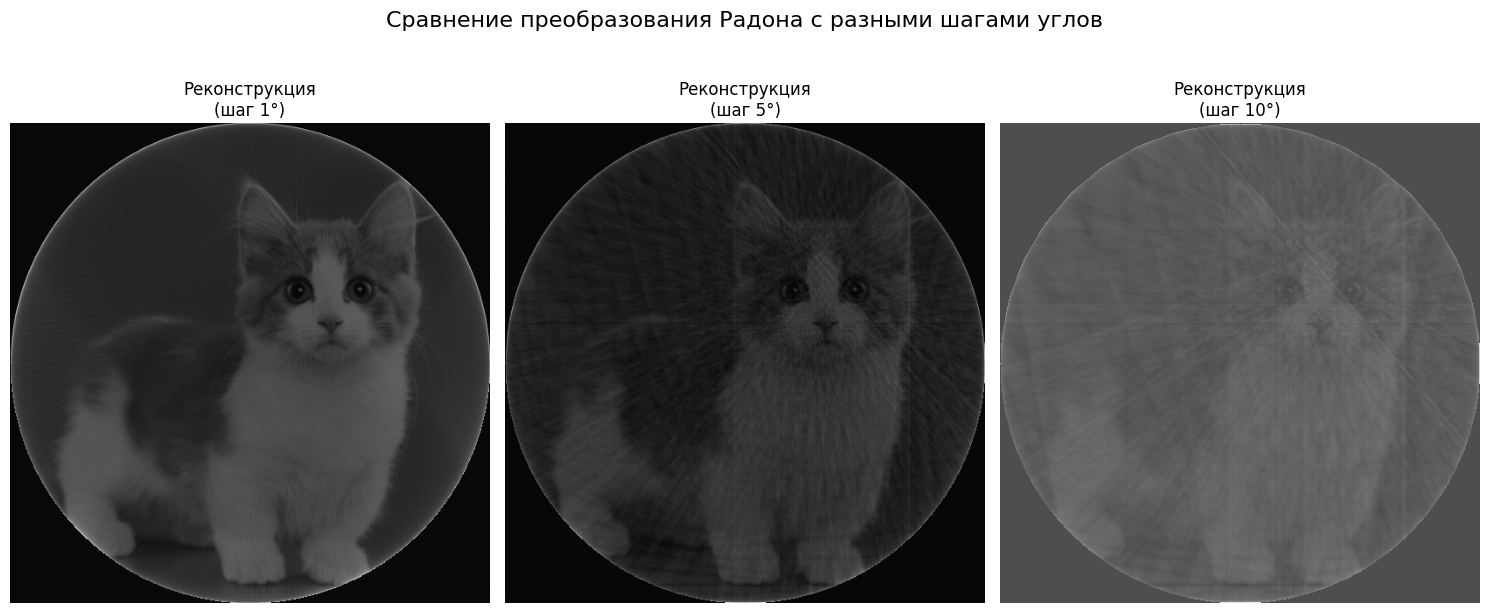

In [ ]:
angles_configurations = [
    {'step': 1, 'theta': np.arange(0, 180, 1)},
    {'step': 5, 'theta': np.arange(0, 180, 5)},
    {'step': 10, 'theta': np.arange(0, 180, 10)}
]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle('Сравнение преобразования Радона с разными шагами углов', fontsize=16)

for i, config in enumerate(angles_configurations):
    step = config['step']
    theta = config['theta']
    n_angles = len(theta)
    
    sinogram = radon(image, theta=theta, circle=True) # Преобразование Радона4
    
    reconstruction = iradon(sinogram, theta=theta, filter_name='ramp', circle=True) # Обратное преобразование Радона
    axes[i].imshow(reconstruction, cmap='gray')
    axes[i].set_title(f'Реконструкция\n(шаг {step}°)')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()